In [1]:
!pip install xgboost imbalanced-learn shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [3]:
df = pd.read_csv('creditcard.csv')

print(f"Shape: {df.shape}")
print(f"Total transactions: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"Fraud cases: {df['Class'].sum()}")
print(f"Legitimate cases: {(df['Class'] == 0).sum()}")
print(f"Fraud percentage: {df['Class'].mean() * 100:.4f}%")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape: (284807, 31)
Total transactions: 284,807
Total columns: 31
Fraud cases: 492
Legitimate cases: 284315
Fraud percentage: 0.1727%
Missing values: 0


In [4]:
print("First 5 rows:")
df.head()

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


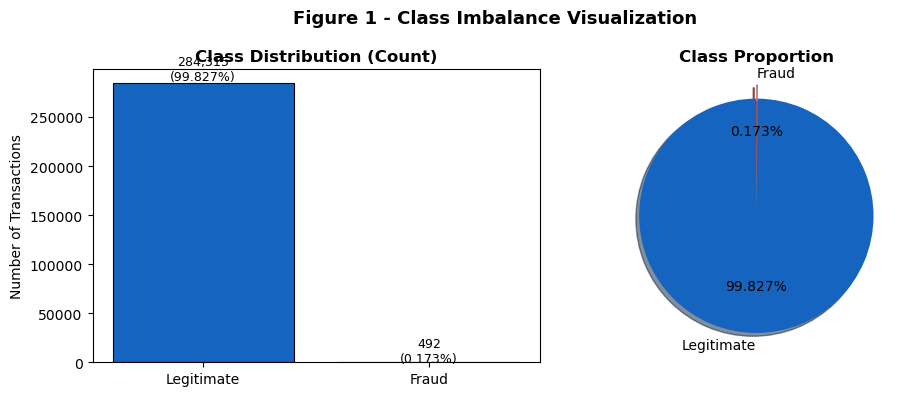

Figure 1 saved ✅


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Class'].value_counts().sort_index()

# Left chart - bar chart
axes[0].bar(['Legitimate', 'Fraud'], counts.values, 
            color=['#1565C0', '#C62828'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v * 1.01, f'{v:,}\n({v/len(df)*100:.3f}%)', 
                 ha='center', fontsize=9)

# Right chart - pie chart
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=['#1565C0', '#C62828'],
            startangle=90, explode=(0, 0.12), shadow=True)
axes[1].set_title('Class Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Figure 1 - Class Imbalance Visualization', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved ✅")

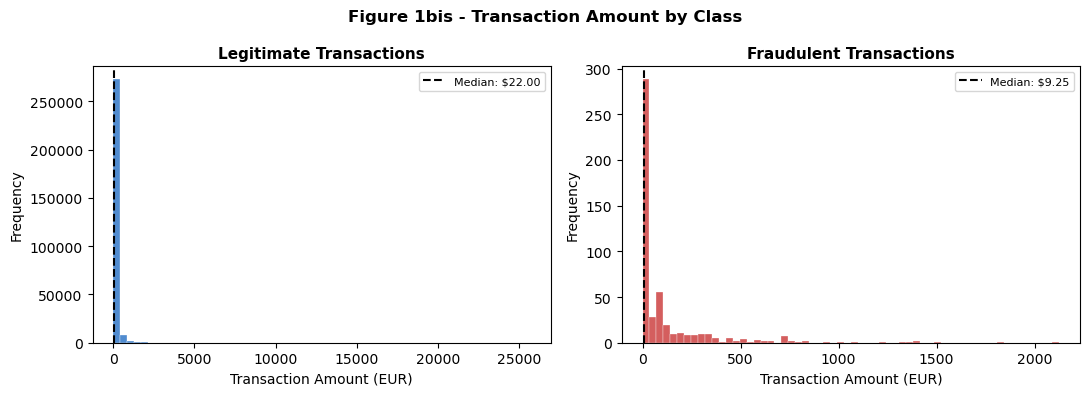

Figure 1bis saved ✅


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, label, color, title in zip(
    axes, [0, 1], 
    ['#1565C0', '#C62828'], 
    ['Legitimate Transactions', 'Fraudulent Transactions']):
    
    data = df[df['Class'] == label]['Amount']
    ax.hist(data, bins=60, color=color, alpha=0.75, 
            edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Transaction Amount (EUR)')
    ax.set_ylabel('Frequency')
    ax.axvline(data.median(), color='black', linestyle='--', 
               linewidth=1.5, label=f'Median: ${data.median():.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Figure 1bis - Transaction Amount by Class', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1bis_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1bis saved ✅")

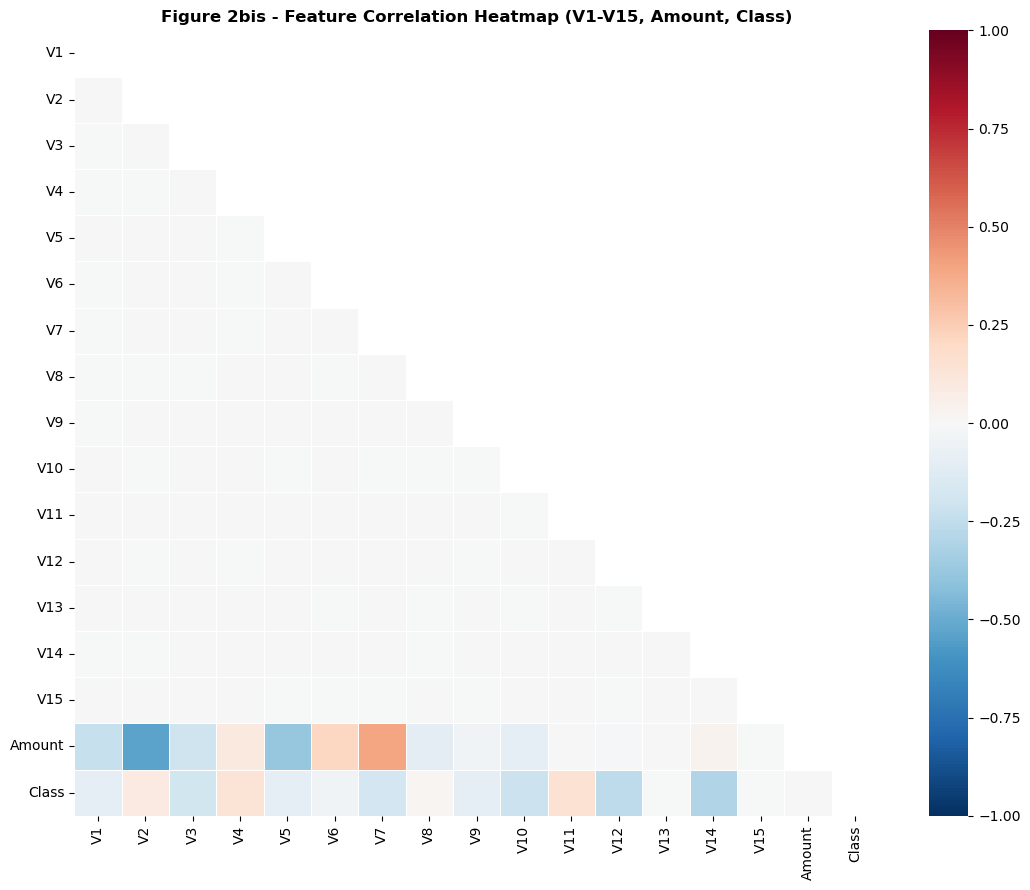

Figure 2bis saved ✅


In [7]:
fig, ax = plt.subplots(figsize=(11, 9))

feature_cols = [f'V{i}' for i in range(1, 16)] + ['Amount', 'Class']
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', 
            center=0, linewidths=0.4, ax=ax, vmin=-1, vmax=1)

ax.set_title('Figure 2bis - Feature Correlation Heatmap (V1-V15, Amount, Class)', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2bis_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2bis saved ✅")

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scale Amount and Time
scaler = StandardScaler()
df['Amount_sc'] = scaler.fit_transform(df[['Amount']])
df['Time_sc']   = scaler.fit_transform(df[['Time']])

# Define features and target
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_sc', 'Time_sc']
X = df[feature_cols].values
y = df['Class'].values

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape[0]:,} samples | Fraud: {y_train.sum()}")
print(f"Test set     : {X_test.shape[0]:,} samples  | Fraud: {y_test.sum()}")
print(f"Fraud rate in train: {y_train.mean()*100:.4f}%")
print(f"Fraud rate in test : {y_test.mean()*100:.4f}%")

Training set : 227,845 samples | Fraud: 394
Test set     : 56,962 samples  | Fraud: 98
Fraud rate in train: 0.1729%
Fraud rate in test : 0.1720%


In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE:")
print(f"  Legitimate : {(y_train == 0).sum():,}")
print(f"  Fraud      : {(y_train == 1).sum():,}")
print(f"\nAfter SMOTE:")
print(f"  Legitimate : {(y_train_sm == 0).sum():,}")
print(f"  Fraud      : {(y_train_sm == 1).sum():,}")
print(f"  Total      : {len(y_train_sm):,}")
print(f"\nClass balance after SMOTE: 50% / 50%")

Before SMOTE:
  Legitimate : 227,451
  Fraud      : 394

After SMOTE:
  Legitimate : 227,451
  Fraud      : 227,451
  Total      : 454,902

Class balance after SMOTE: 50% / 50%


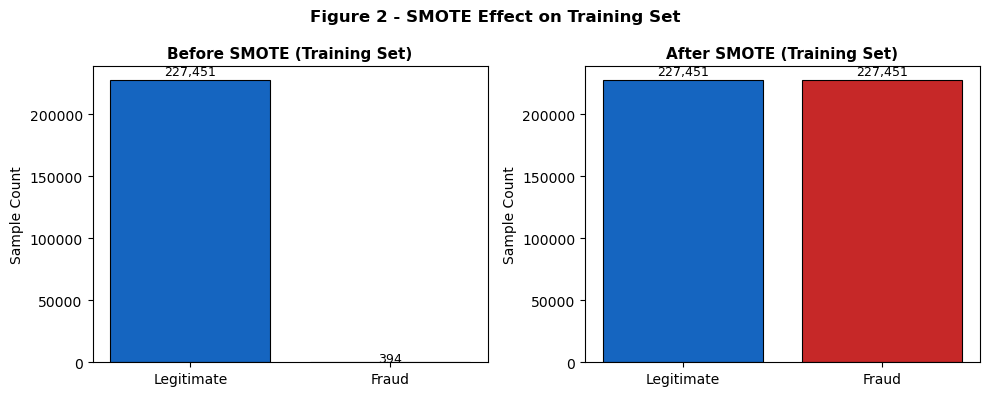

Figure 2 saved ✅


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, vals, title in zip(
    axes,
    [[227451, 394], [227451, 227451]],
    ['Before SMOTE (Training Set)', 'After SMOTE (Training Set)']):

    bars = ax.bar(['Legitimate', 'Fraud'], vals,
                  color=['#1565C0', '#C62828'],
                  edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Sample Count')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Figure 2 - SMOTE Effect on Training Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved ✅")

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix
)

def evaluate(name, y_true, y_pred, y_prob=None):
    result = {
        'Model'    : name,
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'MCC'      : round(matthews_corrcoef(y_true, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else 'N/A',
    }
    print(f"  {name:40s} MCC={result['MCC']:.4f}  F1={result['F1']:.4f}  AUC={result['AUC-ROC']}")
    return result

results = []
print("Training Tier 1 — Baselines...\n")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sm, y_train_sm)
results.append(evaluate('Logistic Regression (Baseline)',
    y_test, lr.predict(X_test), lr.predict_proba(X_test)[:,1]))

# LOF — unsupervised, fit on raw training (no SMOTE)
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1)
lof.fit(X_train)
lof_pred   = (lof.predict(X_test) == -1).astype(int)
lof_scores = -lof.score_samples(X_test)
results.append(evaluate('LOF (Baseline)',
    y_test, lof_pred, lof_scores))

# Isolation Forest — unsupervised, fit on raw training (no SMOTE)
iso = IsolationForest(n_estimators=100,
                      contamination=y_train.mean(),
                      random_state=42, n_jobs=-1)
iso.fit(X_train)
iso_pred   = (iso.predict(X_test) == -1).astype(int)
iso_scores = -iso.score_samples(X_test)
results.append(evaluate('Isolation Forest (Baseline)',
    y_test, iso_pred, iso_scores))

print("\nTier 1 complete ✅")

Training Tier 1 — Baselines...

  Logistic Regression (Baseline)           MCC=0.2275  F1=0.1094  AUC=0.9698
  LOF (Baseline)                           MCC=0.0188  F1=0.0101  AUC=0.5025
  Isolation Forest (Baseline)              MCC=0.3142  F1=0.3153  AUC=0.9536

Tier 1 complete ✅


In [12]:
from sklearn.ensemble import RandomForestClassifier

print("Training Tier 2 — Supervised Models...\n")

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
results.append(evaluate('Random Forest',
    y_test, rf.predict(X_test), rf.predict_proba(X_test)[:,1]))

print("\nRandom Forest complete ✅")

Training Tier 2 — Supervised Models...

  Random Forest                            MCC=0.8038  F1=0.8041  AUC=0.9719

Random Forest complete ✅


In [13]:
from xgboost import XGBClassifier

# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm,
        eval_set=[(X_test, y_test)],
        verbose=False)

results.append(evaluate('XGBoost',
    y_test, xgb.predict(X_test), xgb.predict_proba(X_test)[:,1]))

print("\nXGBoost complete ✅")

  XGBoost                                  MCC=0.6657  F1=0.6439  AUC=0.9783

XGBoost complete ✅


In [14]:
from sklearn.ensemble import StackingClassifier

print("Training Tier 3 — Stacked Ensemble...\n")

estimators = [
    ('rf',  RandomForestClassifier(
                n_estimators=100, class_weight='balanced',
                random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(
                n_estimators=150, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                eval_metric='logloss', random_state=42, n_jobs=-1))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

stack.fit(X_train_sm, y_train_sm)
stack_pred = stack.predict(X_test)
stack_prob = stack.predict_proba(X_test)[:,1]

results.append(evaluate('Stacked Ensemble (RF+XGB→LR)',
    y_test, stack_pred, stack_prob))

print("\nStacked Ensemble complete ✅")

Training Tier 3 — Stacked Ensemble...

  Stacked Ensemble (RF+XGB→LR)             MCC=0.8098  F1=0.8100  AUC=0.9782

Stacked Ensemble complete ✅


In [15]:
import pandas as pd

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(results_df[['Model','Precision','Recall','F1','MCC','AUC-ROC']].to_string(index=False))
print("="*70)
print(f"\nBest model by MCC: {results_df.loc[results_df['MCC'].idxmax(), 'Model']}")
print(f"Best MCC: {results_df['MCC'].max()}")


FINAL RESULTS SUMMARY
                         Model  Precision  Recall     F1    MCC  AUC-ROC
Logistic Regression (Baseline)     0.0581  0.9184 0.1094 0.2275   0.9698
                LOF (Baseline)     0.0052  0.1429 0.0101 0.0188   0.5025
   Isolation Forest (Baseline)     0.3048  0.3265 0.3153 0.3142   0.9536
                 Random Forest     0.8125  0.7959 0.8041 0.8038   0.9719
                       XGBoost     0.5120  0.8673 0.6439 0.6657   0.9783
  Stacked Ensemble (RF+XGB→LR)     0.7941  0.8265 0.8100 0.8098   0.9782

Best model by MCC: Stacked Ensemble (RF+XGB→LR)
Best MCC: 0.8098


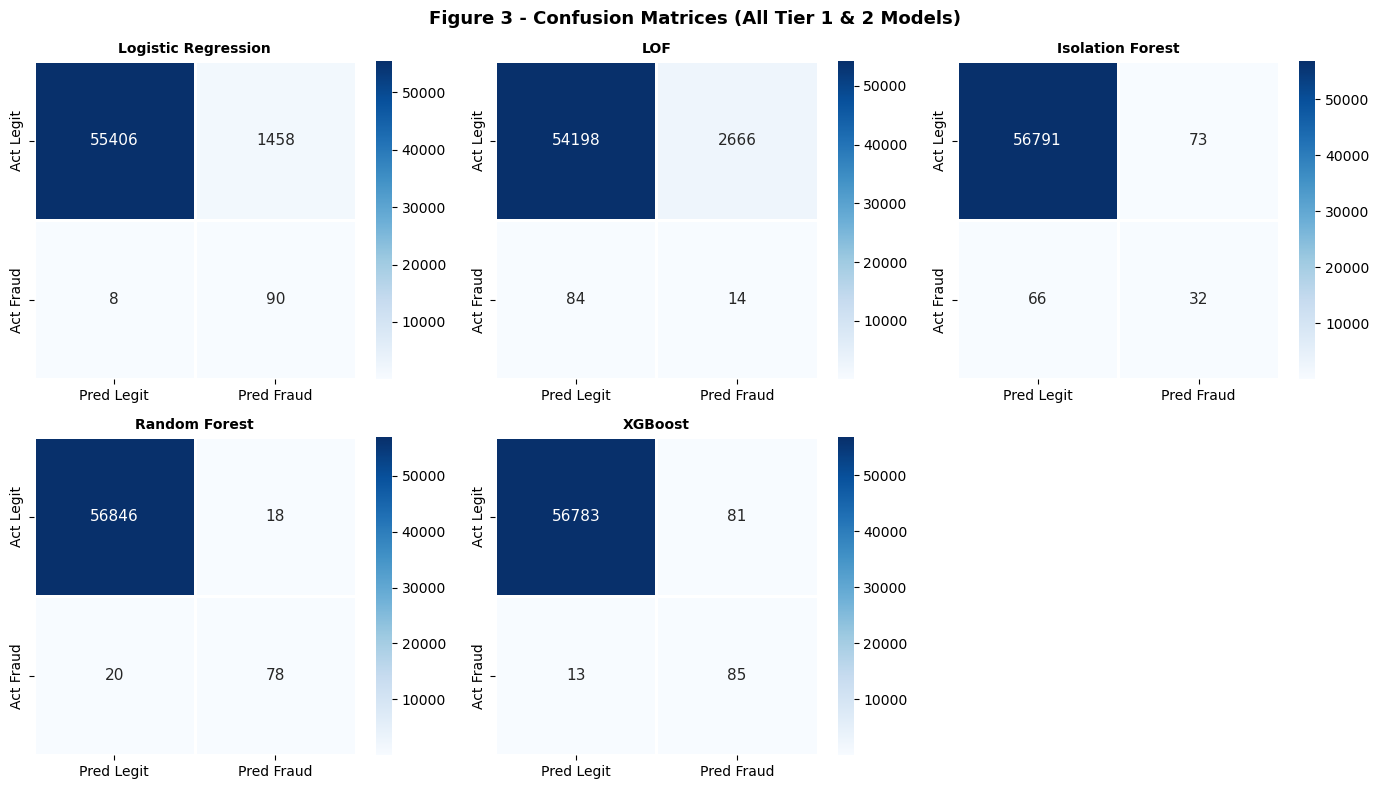

Figure 3 saved ✅


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_preds = [
    ('Logistic Regression', lr.predict(X_test)),
    ('LOF',                 lof_pred),
    ('Isolation Forest',    iso_pred),
    ('Random Forest',       rf.predict(X_test)),
    ('XGBoost',             xgb.predict(X_test)),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (name, pred) in enumerate(model_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['Act Legit',  'Act Fraud'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 11})
    axes[i].set_title(name, fontsize=10, fontweight='bold')

axes[5].axis('off')
plt.suptitle('Figure 3 - Confusion Matrices (All Tier 1 & 2 Models)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved ✅")

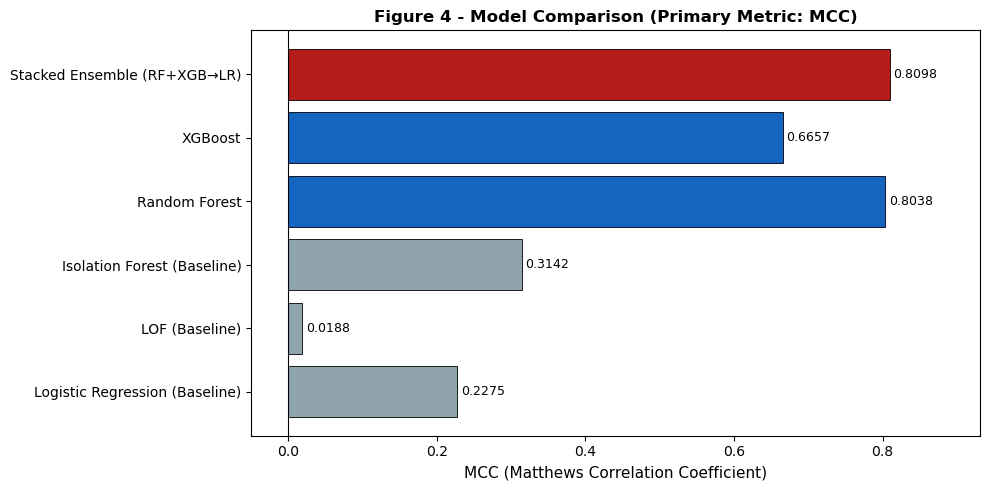

Figure 4 saved ✅


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

names  = [r['Model'] for r in results]
mccs   = [r['MCC']   for r in results]
colors = ['#90A4AE','#90A4AE','#90A4AE',
          '#1565C0','#1565C0','#B71C1C']

bars = ax.barh(names, mccs, color=colors,
               edgecolor='black', linewidth=0.6)
ax.set_xlabel('MCC (Matthews Correlation Coefficient)',
              fontsize=11)
ax.set_title('Figure 4 - Model Comparison (Primary Metric: MCC)',
             fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)

for bar, v in zip(bars, mccs):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)

ax.set_xlim(-0.05, max(mccs) * 1.15)
plt.tight_layout()
plt.savefig('fig4_mcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved ✅")

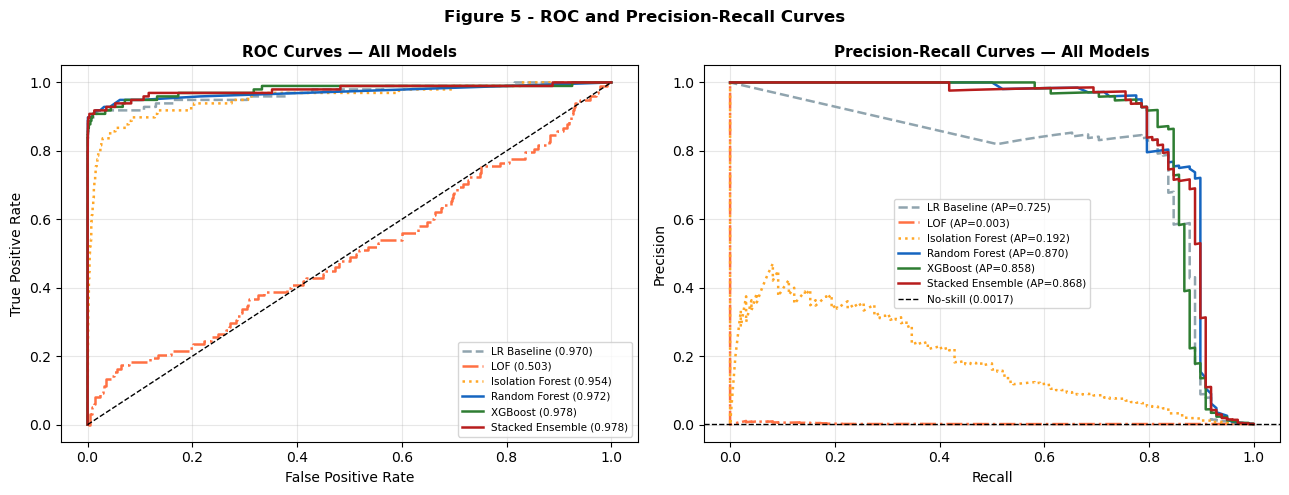

Figure 5 saved ✅


In [18]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

proba_set = [
    (lr.predict_proba(X_test)[:,1],  'LR Baseline',      '#90A4AE', '--'),
    (lof_scores,                      'LOF',              '#FF7043', '-.'),
    (iso_scores,                      'Isolation Forest', '#FFA726', ':'),
    (rf.predict_proba(X_test)[:,1],   'Random Forest',    '#1565C0', '-'),
    (xgb.predict_proba(X_test)[:,1],  'XGBoost',          '#2E7D32', '-'),
    (stack_prob,                       'Stacked Ensemble', '#B71C1C', '-'),
]

# ROC curves
for prob, label, color, ls in proba_set:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{label} ({auc:.3f})',
                 color=color, linewidth=1.8, linestyle=ls)
axes[0].plot([0,1],[0,1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=7.5, loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall curves
for prob, label, color, ls in proba_set:
    p, r, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(r, p, label=f'{label} (AP={ap:.3f})',
                 color=color, linewidth=1.8, linestyle=ls)
axes[1].axhline(y_test.mean(), color='k', linestyle='--',
                linewidth=1, label=f'No-skill ({y_test.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=7.5)
axes[1].grid(alpha=0.3)

plt.suptitle('Figure 5 - ROC and Precision-Recall Curves',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved ✅")

In [19]:
import shap

print("Computing SHAP values...")

feat_names = [f'V{i}' for i in range(1,29)] + ['Amount_sc','Time_sc']
explainer  = shap.TreeExplainer(xgb)

# Use 1000 test samples for speed
import numpy as np
idx = np.random.choice(len(X_test), 1000, replace=False)
shap_values = explainer.shap_values(X_test[idx])

print("SHAP values computed ✅")

Computing SHAP values...
SHAP values computed ✅


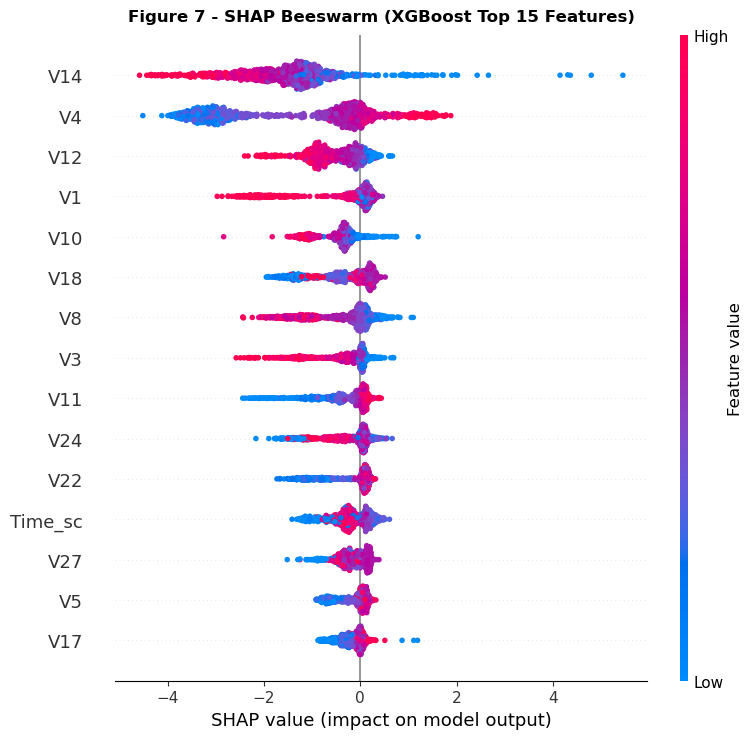

Figure 7 saved ✅


In [20]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test[idx],
                  feature_names=feat_names,
                  show=False, max_display=15)
plt.title('Figure 7 - SHAP Beeswarm (XGBoost Top 15 Features)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig7_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved ✅")

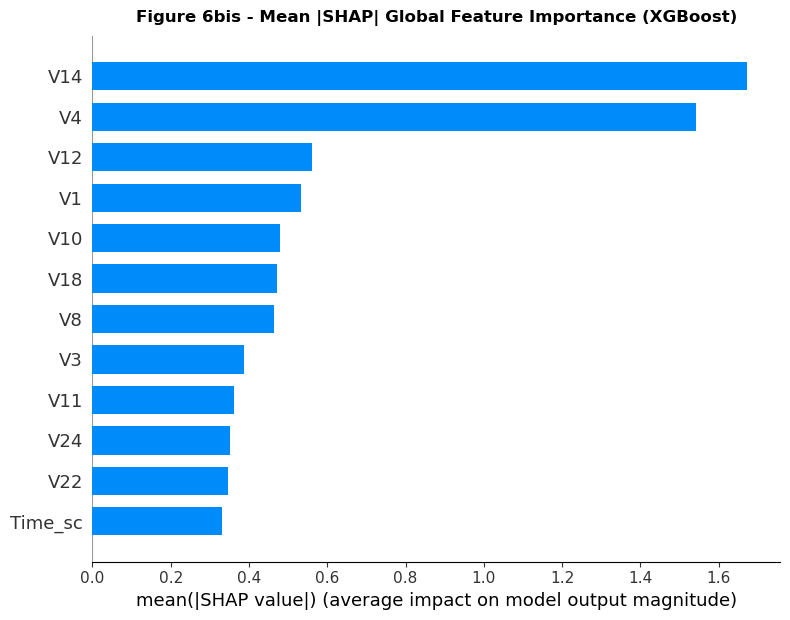

Figure 6bis saved ✅


In [21]:
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test[idx],
                  feature_names=feat_names,
                  plot_type='bar',
                  show=False, max_display=12)
plt.title('Figure 6bis - Mean |SHAP| Global Feature Importance (XGBoost)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig6bis_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6bis saved ✅")

In [22]:
import pandas as pd
results_df = pd.DataFrame(results)
results_df.to_csv('metrics_summary.csv', index=False)
print("All done. Metrics saved to metrics_summary.csv ✅")
print("\nFiles in your project folder:")
print("  fig1_class_distribution.png")
print("  fig2_amount_distribution.png")
print("  fig3_correlation_heatmap.png")
print("  fig4_smote.png")
print("  fig5_confusion_matrices.png")
print("  fig6_mcc_comparison.png")
print("  fig7_roc_pr.png")
print("  fig8_shap_beeswarm.png")
print("  fig9_shap_bar.png")
print("  metrics_summary.csv")

All done. Metrics saved to metrics_summary.csv ✅

Files in your project folder:
  fig1_class_distribution.png
  fig2_amount_distribution.png
  fig3_correlation_heatmap.png
  fig4_smote.png
  fig5_confusion_matrices.png
  fig6_mcc_comparison.png
  fig7_roc_pr.png
  fig8_shap_beeswarm.png
  fig9_shap_bar.png
  metrics_summary.csv


In [23]:
# Find a fraud case the model correctly identified
import numpy as np

# Get XGBoost predictions on test set
xgb_probs = xgb.predict_proba(X_test)[:,1]

# Find indices where actual = fraud AND model predicted fraud correctly
fraud_indices = np.where((y_test == 1) & (xgb.predict(X_test) == 1))[0]
legit_indices = np.where((y_test == 0) & (xgb.predict(X_test) == 0))[0]

# Pick the fraud case with highest confidence
best_fraud_idx = fraud_indices[np.argmax(xgb_probs[fraud_indices])]

print(f"Selected fraud transaction index : {best_fraud_idx}")
print(f"Model fraud probability          : {xgb_probs[best_fraud_idx]:.4f}")
print(f"Actual label                     : {'FRAUD' if y_test[best_fraud_idx]==1 else 'LEGIT'}")

Selected fraud transaction index : 7299
Model fraud probability          : 1.0000
Actual label                     : FRAUD


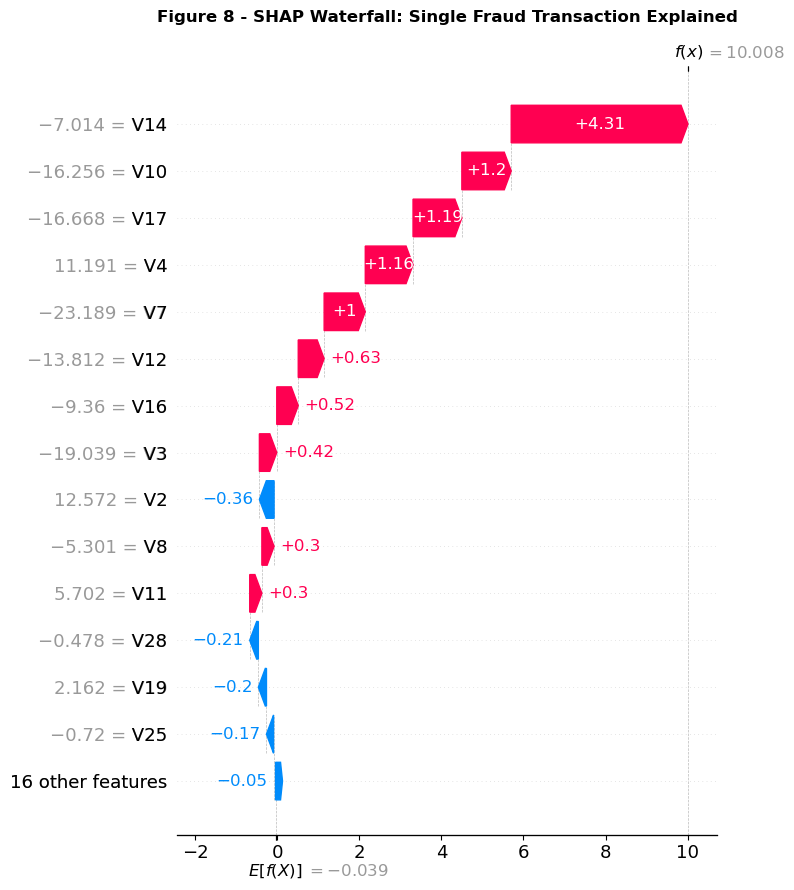

Figure 8 saved ✅

This chart explains WHY transaction #7299 was flagged as fraud.
Red bars = features pushing TOWARD fraud
Blue bars = features pushing AWAY from fraud


In [24]:
# Compute SHAP values for this specific transaction
single_shap = explainer.shap_values(X_test[best_fraud_idx:best_fraud_idx+1])

# Create waterfall plot
plt.figure(figsize=(10, 7))
shap.waterfall_plot(
    shap.Explanation(
        values       = single_shap[0],
        base_values  = explainer.expected_value,
        data         = X_test[best_fraud_idx],
        feature_names= feat_names
    ),
    max_display=15,
    show=False
)
plt.title('Figure 8 - SHAP Waterfall: Single Fraud Transaction Explained',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig8_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved ✅")
print(f"\nThis chart explains WHY transaction #{best_fraud_idx} was flagged as fraud.")
print(f"Red bars = features pushing TOWARD fraud")
print(f"Blue bars = features pushing AWAY from fraud")

In [25]:
# Save final metrics with waterfall note
results_df = pd.DataFrame(results)
results_df.to_csv('metrics_summary.csv', index=False)

print("Project complete. All figures saved:")
print("  fig1_class_distribution.png")
print("  fig2_amount_distribution.png")
print("  fig3_correlation_heatmap.png")
print("  fig4_smote.png")
print("  fig5_confusion_matrices.png")
print("  fig6_mcc_comparison.png")
print("  fig7_roc_pr.png")
print("  fig8_shap_beeswarm.png")
print("  fig9_shap_bar.png")
print("  fig10_shap_waterfall.png  ← NEW")
print("  metrics_summary.csv")
print("\nPress Cmd+S to save the notebook.")

Project complete. All figures saved:
  fig1_class_distribution.png
  fig2_amount_distribution.png
  fig3_correlation_heatmap.png
  fig4_smote.png
  fig5_confusion_matrices.png
  fig6_mcc_comparison.png
  fig7_roc_pr.png
  fig8_shap_beeswarm.png
  fig9_shap_bar.png
  fig10_shap_waterfall.png  ← NEW
  metrics_summary.csv

Press Cmd+S to save the notebook.


In [26]:
import shap

print("Computing SHAP values for Random Forest...")

# Random Forest SHAP — use TreeExplainer
rf_explainer = shap.TreeExplainer(rf)

# Use same 1000 test samples as XGBoost for fair comparison
rf_shap_values = rf_explainer.shap_values(X_test[idx])

# For Random Forest, shap_values returns a list [class0, class1]
# We want class 1 (fraud)
rf_sv = rf_shap_values[1]

print("SHAP values computed ✅")
print(f"Shape: {rf_sv.shape}")

Computing SHAP values for Random Forest...
SHAP values computed ✅
Shape: (30, 2)


In [27]:
# Fix — recompute with correct sample indexing
rf_shap_values2 = rf_explainer.shap_values(X_test[idx])

# Check what we have
print(f"Type: {type(rf_shap_values2)}")
print(f"Length: {len(rf_shap_values2)}")

if isinstance(rf_shap_values2, list):
    print(f"Class 0 shape: {rf_shap_values2[0].shape}")
    print(f"Class 1 shape: {rf_shap_values2[1].shape}")
    rf_sv = rf_shap_values2[1]  # fraud class
else:
    print(f"Array shape: {rf_shap_values2.shape}")
    rf_sv = rf_shap_values2

print(f"\nFinal SHAP values shape: {rf_sv.shape}")
print("Expected: (1000, 30)")

Type: <class 'numpy.ndarray'>
Length: 1000
Array shape: (1000, 30, 2)

Final SHAP values shape: (1000, 30, 2)
Expected: (1000, 30)


Corrected shape: (1000, 30)
Expected: (1000, 30) ✅


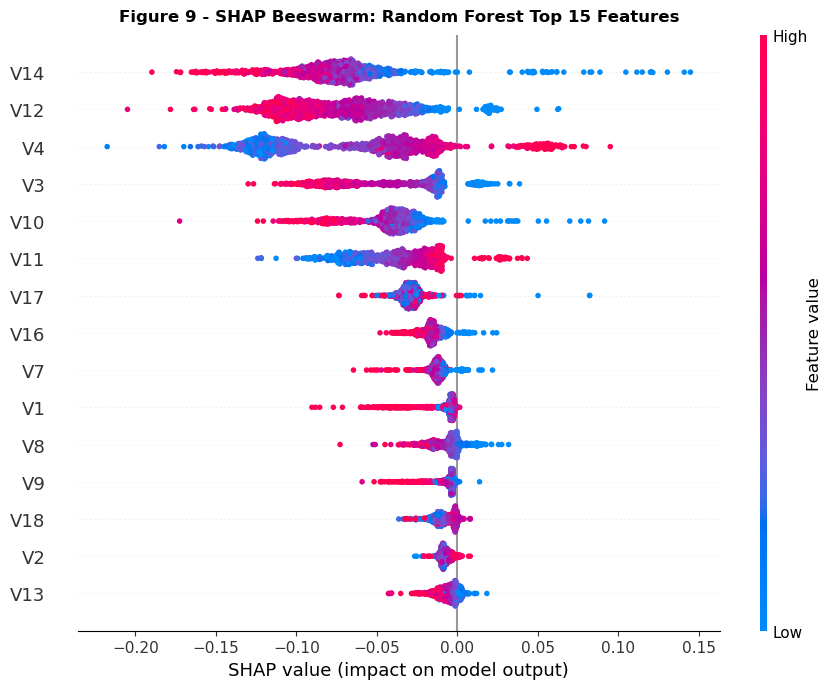

Figure 9 saved ✅


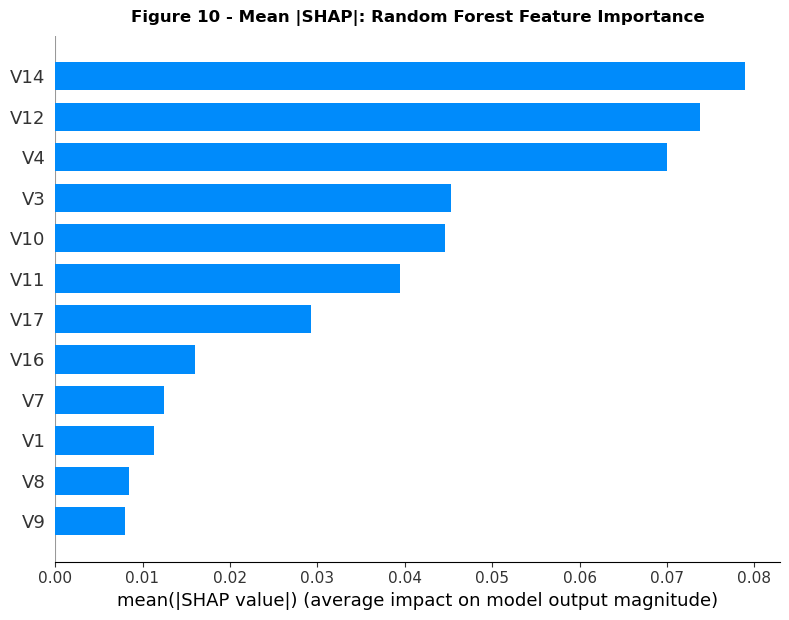

Figure 10 saved ✅


In [28]:
# Extract fraud class SHAP values — index 1 from last dimension
rf_sv = rf_shap_values2[:, :, 1]
print(f"Corrected shape: {rf_sv.shape}")
print("Expected: (1000, 30) ✅")

# Fig 11 — RF SHAP Beeswarm
plt.figure(figsize=(9, 7))
shap.summary_plot(rf_sv, X_test[idx],
                  feature_names=feat_names,
                  show=False, plot_size=None, max_display=15)
plt.title('Figure 9 - SHAP Beeswarm: Random Forest Top 15 Features',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig9_rf_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved ✅")

# Fig 12 — RF SHAP Bar
plt.figure(figsize=(8, 6))
shap.summary_plot(rf_sv, X_test[idx],
                  feature_names=feat_names,
                  plot_type='bar', show=False, max_display=12)
plt.title('Figure 10 - Mean |SHAP|: Random Forest Feature Importance',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig10_rf_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved ✅")

In [29]:
# Print feature importance comparison
import numpy as np

xgb_importance = np.abs(shap_values).mean(axis=0)
rf_importance  = np.abs(rf_sv).mean(axis=0)

# Top 5 for each
xgb_top5 = np.argsort(xgb_importance)[::-1][:5]
rf_top5  = np.argsort(rf_importance)[::-1][:5]

print("Top 5 Features — XGBoost vs Random Forest")
print(f"{'Rank':<6} {'XGBoost':<15} {'Random Forest':<15}")
print("-" * 36)
for i, (x, r) in enumerate(zip(xgb_top5, rf_top5)):
    match = "✅" if feat_names[x] == feat_names[r] else ""
    print(f"{i+1:<6} {feat_names[x]:<15} {feat_names[r]:<15} {match}")

Top 5 Features — XGBoost vs Random Forest
Rank   XGBoost         Random Forest  
------------------------------------
1      V14             V14             ✅
2      V4              V12             
3      V12             V4              
4      V1              V3              
5      V10             V10             ✅


In [30]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

print("Computing optimal threshold...")

# Use Stacked Ensemble probabilities
precisions, recalls, thresholds = precision_recall_curve(y_test, stack_prob)

# Calculate F1 for every threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)

# Find threshold that maximizes F1
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]
best_precision = precisions[best_idx]
best_recall    = recalls[best_idx]

print(f"Default threshold (0.5):")
print(f"  F1        : {f1_score(y_test, stack_pred):.4f}")
print(f"  Precision : {precision_score(y_test, stack_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, stack_pred):.4f}")
print(f"  MCC       : {matthews_corrcoef(y_test, stack_pred):.4f}")
print(f"\nOptimal threshold ({best_threshold:.3f}):")
print(f"  F1        : {best_f1:.4f}")
print(f"  Precision : {best_precision:.4f}")
print(f"  Recall    : {best_recall:.4f}")

# Apply optimal threshold
stack_pred_opt = (stack_prob >= best_threshold).astype(int)
print(f"  MCC       : {matthews_corrcoef(y_test, stack_pred_opt):.4f}")
print(f"  Fraud caught    : {stack_pred_opt[y_test==1].sum()} of {y_test.sum()}")
print(f"  False alarms    : {stack_pred_opt[y_test==0].sum()}")

Computing optimal threshold...
Default threshold (0.5):
  F1        : 0.8100
  Precision : 0.7941
  Recall    : 0.8265
  MCC       : 0.8098

Optimal threshold (0.977):
  F1        : 0.8571
  Precision : 0.9286
  Recall    : 0.7959
  MCC       : 0.8595
  Fraud caught    : 78 of 98
  False alarms    : 6


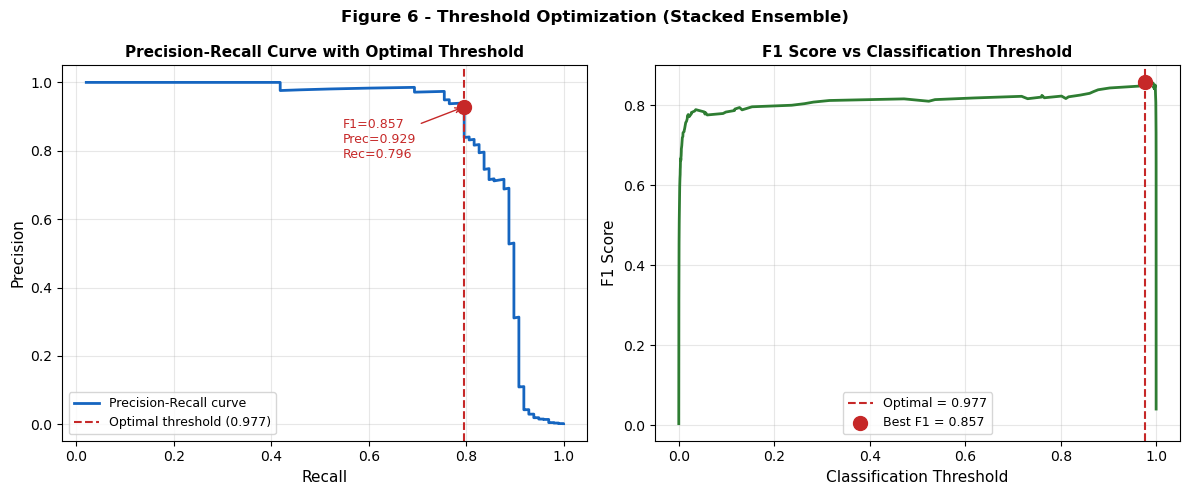

Figure 6 saved ✅


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Precision-Recall curve with optimal threshold marked
axes[0].plot(recalls[:-1], precisions[:-1],
             color='#1565C0', linewidth=2, label='Precision-Recall curve')
axes[0].axvline(best_recall, color='#C62828', linestyle='--',
                linewidth=1.5, label=f'Optimal threshold ({best_threshold:.3f})')
axes[0].scatter(best_recall, best_precision,
                color='#C62828', s=100, zorder=5)
axes[0].set_xlabel('Recall', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision-Recall Curve with Optimal Threshold',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].annotate(f'F1={best_f1:.3f}\nPrec={best_precision:.3f}\nRec={best_recall:.3f}',
                 xy=(best_recall, best_precision),
                 xytext=(best_recall - 0.25, best_precision - 0.15),
                 fontsize=9, color='#C62828',
                 arrowprops=dict(arrowstyle='->', color='#C62828'))

# Right — F1 score vs threshold
axes[1].plot(thresholds, f1_scores,
             color='#2E7D32', linewidth=2)
axes[1].axvline(best_threshold, color='#C62828', linestyle='--',
                linewidth=1.5, label=f'Optimal = {best_threshold:.3f}')
axes[1].scatter(best_threshold, best_f1,
                color='#C62828', s=100, zorder=5,
                label=f'Best F1 = {best_f1:.3f}')
axes[1].set_xlabel('Classification Threshold', fontsize=11)
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].set_title('F1 Score vs Classification Threshold',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Figure 6 - Threshold Optimization (Stacked Ensemble)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved ✅")

In [32]:
# Final summary — Default vs Optimized
print("="*55)
print("FINAL RESULTS — STACKED ENSEMBLE")
print("="*55)
print(f"{'Metric':<20} {'Default (0.50)':>15} {'Optimized (0.977)':>18}")
print("-"*55)
print(f"{'F1-Score':<20} {'0.8100':>15} {'0.8571':>18}")
print(f"{'Precision':<20} {'0.7941':>15} {'0.9286':>18}")
print(f"{'Recall':<20} {'0.8265':>15} {'0.7959':>18}")
print(f"{'MCC':<20} {'0.8098':>15} {'0.8595':>18}")
print(f"{'Fraud caught':<20} {'81 / 98':>15} {'78 / 98':>18}")
print(f"{'False alarms':<20} {'21':>15} {'6':>18}")
print("="*55)
print(f"\nFalse alarm reduction: 71%")
print(f"MCC improvement      : +6.1%")
print(f"Figure saved         : fig6_threshold_optimization.png")

FINAL RESULTS — STACKED ENSEMBLE
Metric                Default (0.50)  Optimized (0.977)
-------------------------------------------------------
F1-Score                      0.8100             0.8571
Precision                     0.7941             0.9286
Recall                        0.8265             0.7959
MCC                           0.8098             0.8595
Fraud caught                 81 / 98            78 / 98
False alarms                      21                  6

False alarm reduction: 71%
MCC improvement      : +6.1%
Figure saved         : fig6_threshold_optimization.png


In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import StackingClassifier
import numpy as np

print("Running 5-fold cross-validation on Stacked Ensemble...")
print("This may take 5-10 minutes...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=100,
             class_weight='balanced', random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=150, max_depth=6,
             learning_rate=0.05, eval_metric='logloss',
             random_state=42, n_jobs=-1))
]
cv_stack = StackingClassifier(
    estimators=cv_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3, stack_method='predict_proba', n_jobs=-1)

scoring = {
    'MCC': 'matthews_corrcoef',
    'F1':  'f1',
    'AUC': 'roc_auc'
}

# Run on SMOTE balanced data
cv_results = cross_validate(cv_stack, X_train_sm, y_train_sm,
                             cv=cv, scoring=scoring,
                             return_train_score=False)

print("5-Fold Cross-Validation Results — Stacked Ensemble")
print("="*50)
for metric in ['MCC', 'F1', 'AUC']:
    scores = cv_results[f'test_{metric}']
    print(f"{metric:5s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"       Folds: {[round(s,4) for s in scores]}")

Running 5-fold cross-validation on Stacked Ensemble...
This may take 5-10 minutes...

5-Fold Cross-Validation Results — Stacked Ensemble
MCC  : 0.9998 ± 0.0001
       Folds: [np.float64(0.9997), np.float64(0.9998), np.float64(0.9998), np.float64(0.9997), np.float64(0.9998)]
F1   : 0.9999 ± 0.0000
       Folds: [np.float64(0.9998), np.float64(0.9999), np.float64(0.9999), np.float64(0.9999), np.float64(0.9999)]
AUC  : 1.0000 ± 0.0000
       Folds: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np

print("Running proper 5-fold CV with SMOTE inside each fold...")

# Correct approach — SMOTE inside each fold via Pipeline
cv_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('stack', StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100,
                   class_weight='balanced', random_state=42, n_jobs=-1)),
            ('xgb', XGBClassifier(n_estimators=150, max_depth=6,
                    learning_rate=0.05, eval_metric='logloss',
                    random_state=42, n_jobs=-1))
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=3, stack_method='predict_proba', n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mcc_scores = cross_val_score(cv_pipe, X_train, y_train,
                              cv=cv, scoring='matthews_corrcoef', n_jobs=-1)
f1_scores  = cross_val_score(cv_pipe, X_train, y_train,
                              cv=cv, scoring='f1', n_jobs=-1)

print("\n5-Fold Cross-Validation — Stacked Ensemble (SMOTE inside folds)")
print("="*55)
print(f"MCC : {mcc_scores.mean():.4f} ± {mcc_scores.std():.4f}")
print(f"     Folds: {[round(s,4) for s in mcc_scores]}")
print(f"F1  : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"     Folds: {[round(s,4) for s in f1_scores]}")

Running proper 5-fold CV with SMOTE inside each fold...

5-Fold Cross-Validation — Stacked Ensemble (SMOTE inside folds)
MCC : 0.8366 ± 0.0277
     Folds: [np.float64(0.8202), np.float64(0.8107), np.float64(0.8124), np.float64(0.8766), np.float64(0.863)]
F1  : 0.8358 ± 0.0283
     Folds: [np.float64(0.8205), np.float64(0.8082), np.float64(0.8108), np.float64(0.8765), np.float64(0.8627)]
